#XGBOOST

In [27]:
from pyspark.ml.feature import VectorAssembler
from xgboost.spark import SparkXGBClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.evaluation import BinaryClassificationEvaluator

In [28]:
# Vector Assembler

df = df.withColumnRenamed("Loan_Status", "label")


assembler = VectorAssembler( inputCols = [
    "Age",
    "Income",
    "LoanAmount",
    "Credit_Score",
    "Employment_Years",
    "Credit_History",
    "Has_Defaulted",
    "Dependents",
    "Gender",
    "Education_Level",
    "Married",
    "Job_Type",
    "Property_Area"
],
outputCol = "features",
handleInvalid = "keep"
)

df_final = assembler.transform(df)

In [29]:
# Train and Test split

train_df, test_df = df_final.randomSplit([0.8, 0.2], seed = 42)

#XGBoost Model (Spark)

In [47]:
xgb = SparkXGBClassifier(
    features_col="features",
    label_col="label",
    prediction_col="prediction",
    probability_col="probability",
    max_depth=6,
    eta=0.1,
    num_round=100
)

In [48]:
model = xgb.fit(train_df)

INFO:XGBoost-PySpark:Running xgboost-3.2.0 on 1 workers with
	booster params: {'objective': 'binary:logistic', 'device': 'cpu', 'max_depth': 6, 'eta': 0.1, 'num_round': 100, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 100}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
INFO:XGBoost-PySpark:Finished xgboost training!


In [49]:
predictions = model.transform(test_df)
predictions.select("label", "prediction", "probability").show(10)

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|    0|       0.0|[0.95937120914459...|
|    1|       1.0|[0.40401041507720...|
|    0|       0.0|[0.97973084449768...|
|    1|       1.0|[0.11599409580230...|
|    0|       0.0|[0.95239037275314...|
|    0|       0.0|[0.83780628442764...|
|    1|       0.0|[0.85575747489929...|
|    1|       1.0|[0.03742492198944...|
|    1|       1.0|[0.24065315723419...|
|    1|       1.0|[0.02303493022918...|
+-----+----------+--------------------+
only showing top 10 rows


#Evaluation

Accuracy

In [50]:
acc_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

print("accuracy : ", acc_eval.evaluate(predictions))

accuracy :  0.821635607215136


F1-score

In [51]:
f1_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

print("f1 :", f1_eval.evaluate(predictions))

f1 : 0.8202294998487633


AUC

In [52]:
auc_eval = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

print("areaUnderROC :", auc_eval.evaluate(predictions))

areaUnderROC : 0.8993500171056316


In [53]:
model.get_feature_importances()

{'f0': 512.0,
 'f1': 1088.0,
 'f2': 1490.0,
 'f3': 615.0,
 'f4': 543.0,
 'f5': 335.0,
 'f6': 321.0,
 'f7': 327.0,
 'f8': 47.0,
 'f9': 251.0,
 'f10': 140.0,
 'f11': 344.0,
 'f12': 253.0}

#Visualization XGBOOST

Confusion Matrix

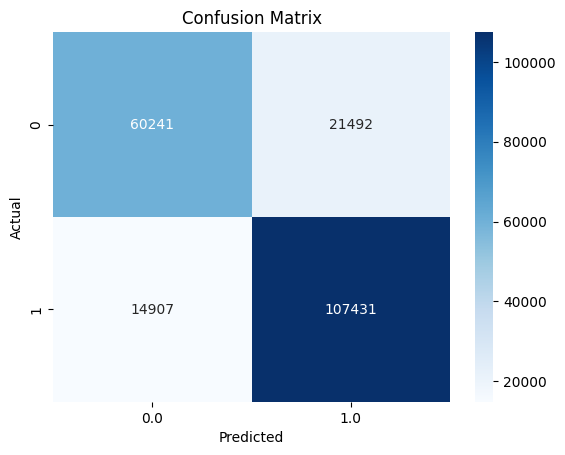

In [56]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pred_pd = predictions.select("label", "prediction").toPandas()

cm = pd.crosstab(pred_pd["label"], pred_pd["prediction"])

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

ROC Curve

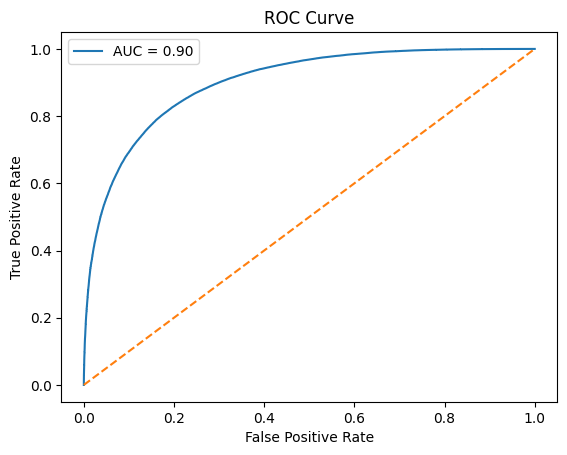

In [57]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

pred_pd = predictions.select("label", "probability").toPandas()

y_true = predictions.select("label").toPandas()["label"]
y_score = pred_pd["probability"].apply(lambda x: float(x[1]))

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], '--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

Feature Importance

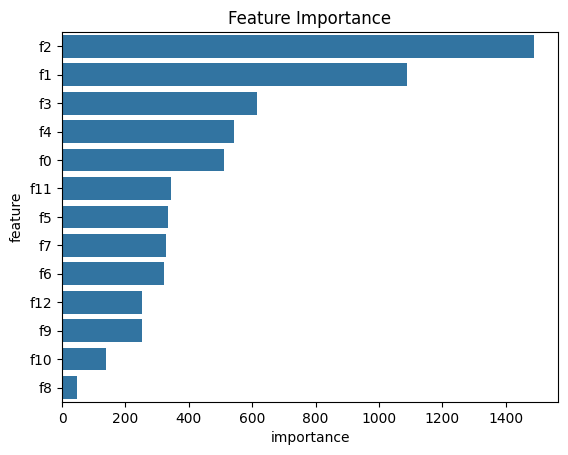

In [58]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

importance = model.get_feature_importances()

fi = pd.DataFrame({
    "feature": list(importance.keys()),
    "importance": list(importance.values())
}).sort_values(by="importance", ascending=False)

sns.barplot(x="importance", y="feature", data=fi)
plt.title("Feature Importance")
plt.show()